# Cell list

The sampling keeps its computational complexity managable by dividing the box up into cells that are just a bit larger than one particle diameter, which one could achieve, for example, by setting the number of divisions to $\left\lfloor\frac{L}{\sigma}\right\rfloor$ where $L$ is simulation box size and $\sigma$ particle diameter. The reason for this is that particle pairs that are not in the same cell or neighbouring cells are definitely out of their interaction range $\sigma$, making it redundant to compute their potential energy.

For this reason we can, in fact, also safely update cells that are two apart at the same time. Cells will be two apart if we give any given cell of an update group an immediate neighbourhood of cells (as skin, if you will) of thickness one, which will be $3^d$ in count; every part of this representative cell neighbourhood can be thought of as standing for the entire parallel-updating group. The number of divisions will have to divide $3$ for this to fit cleanly, so the number of divisions we choose is $$3\left\lfloor\frac{1}{3}\frac{L}{\sigma}\right\rfloor$$

# Limits to move magnitude

The limit to the size of moves is one particle diameter, since otherwise two particles from the same cell group could potentially interact


# Illustration
![Illustration of why half a particle diameter is the worst-case upper bound for move size](cell_list_illustration.png)
<!-- <div style="text-align: center;"><img src="cell_list_illustration.png" alt="Illustration of why half a particle diameter is the worst-case upper bound for move size" width="50%"></div> -->

In [19]:
import numpy as np
import numba as nb

In [20]:
from math import lgamma

@nb.njit
def B(d):
    '''-
    Returns the hyper-volume of the unit ball
    in d dimensions
    
    Args:
		d:
			the number of spatial dimensions the (hyper-)unit
            ball exists in

    https://en.wikipedia.org/wiki/N-sphere#Volume_and_area
    '''
    gamma_of_1_plus_d_over_2 = np.exp(lgamma(1 + d/2))
    return np.pi**(d/2) / gamma_of_1_plus_d_over_2

In [21]:
@nb.njit
def __inflate_flattened_index(
	flattened_index,
	spatial_dimension_count,
	indices_per_dimension):
	'''
	Computes the multiindex (i_0, i_1, ..., i_{d-1}) from the
	flattened cell index i_0 + i_1 * M + ... + i_{d-1} * M^(d-1)
		
	Args:
		flattened_index:
			the flattened index to inflate
		spatial_dimension_count:
			d from the above description
		indicies_per_dimension:
			M from the above description
		
	Returns:
		(i_0, i_1, ..., i_{d-1}) as an np.int64 array with d entries
	'''
	flattened_index_copy = int(flattened_index) # making a copy
	inflated_multiindex = np.zeros(spatial_dimension_count, dtype=np.int64) # output for later 
	for k in range(spatial_dimension_count):
		# let M = indices_per_dimension for brevity:
		# flattened_index = i_0 + i_1 * M + i_2 * M^2 + ... + i_{d-1} * M^(d-1), hence ...
		# ... flattened_index % M = i_0, making flattened_index - i_0 = i_1 * M + ..., such ...
		# ... that way may divide out M and repeat the process
		i_k = flattened_index_copy % indices_per_dimension
		inflated_multiindex[k] = i_k
		flattened_index_copy -= i_k
		# TODO dividing is nono. Can you avoid it?
		flattened_index_copy = int(flattened_index_copy / indices_per_dimension)
	return inflated_multiindex



@nb.njit
def __flatten_multiindex(multiindex, spatial_dimension_count, indices_per_dimension):
	'''
	Takes in a multiindex (i_0, i_1, ..., i_{d-1}) and flattens it into
	a cell index i_0 + i_1 * M + ... + i_{d-1} * M^(d-1). If any of the
	i_k exceeds M or falls below 0, i_k % M will be used in its stead.
		
	Args:
		multiindex:
			the (i_0, i_1, ..., i_{d-1}) to be flattened
		spatial_dimension_count:
			the number of spatial directions d implied
		indices_per_dimension:
			starting from 0, the maximum value that the i_k reach
	'''
	flattened_index = 0
	for l in range(spatial_dimension_count):
		flattened_index += int(
			# sparing user from having to watch out for in-range indices and ...
			# ... hence enable them to increment up and down freely
			(multiindex[l] % indices_per_dimension)
			* indices_per_dimension**l
		)
	return flattened_index



@nb.njit
def __repopulate_cell_list(
	x, cell_list,
	divisions, simulation_box_size):
	'''
	takes in the array of positions and fills them into the cell list
		
	Args:
		bin_indices:
			list of bin indices of size spatial_dimension_count
		cell_list:
			the cell_list
		divisions:
			the number of divisions per independent spatial direction
		simulation_box_size:
			the size of the simulation box, given in the same units as
			the particle diameter
	'''
	# retrieving particle number from x
	particle_number, spatial_dimension_count = x.shape
	cell_list_size = len(cell_list)
	# clearing all lists entries
	for i in range(cell_list_size):
		cell_list[i].clear()
	# bin indices are given by flooring
	bin_indices = np.floor(divisions * x / simulation_box_size).astype(np.int64) % divisions
	for k in range(particle_number):
		b_k = bin_indices[k]
		cell_list[__flatten_multiindex(b_k, spatial_dimension_count, divisions)].append(k)

In [22]:
@nb.njit
def u(r, E, sigma):
	'''
	pair potential for penetrable spheres or disks given a radius

	Args:
		r:
			the distance of the particle pair in question
		E:
			the size of the energy step
		sigma:
			the distance at which the energy step happens
	'''
	return E if r < sigma else (E/2 if r == sigma else 0)

In [23]:
@nb.njit
def single_particle_potential_energy(
	# particle information
	# NOTE: we pass x_i separately because we want to move ...
	#		... it relative to x[i] for the metropolis-hastings- ...
	#		... sampling move
	i, x_i, x,
	# which group and cell are we in
	igi, g,
	# dimensionality and cell list
	spatial_dimension_count, divisions,
	cell_list, nearest_neighbour_count,
	lattice_vectors,
	# physical parameters
	overlap_energy,
	sigma
	):
	'''
	Computes the contribution of a single particle to
	potential energy; to be more precise, if i is the
	index of the particle under consideration, then
	we compute the sum of all u(r_ij) over all j != i
	'''
	contribution_to_potential_energy = 0
	# grabbing the positions of all particles in the current and all next neighbouring ...
	# ... cells with a running multiindex-shift n (as in "neighbours"). Note that we first ...
	# ... need to loop over n_k = -1, 0, 1 to then compute from this the shift in cell ...
	# ... index n_0 + n_1 * M + n_2 * M^2 + ... + n_{d-1} * M^(d-1)
	for flattened_index_shift_to_nearest_neighbour in range(nearest_neighbour_count):
		n = __inflate_flattened_index(
			flattened_index_shift_to_nearest_neighbour,
			spatial_dimension_count, 3
		) - 1 # NOTE the minus one maps 0 -> -1 and 1 -> 0 and 2 -> 1, exactly what we want
		nearest_neighbour_cell_index = __flatten_multiindex(
			(3 * igi + g + n),
			spatial_dimension_count,
			divisions
		)
		for j in cell_list[nearest_neighbour_cell_index]:
			# no self-interaction
			if j == i:
				continue
			# TODO 	do not use the watering can like this, be selective and
			#		only consider images which could even be relevant
			for R in lattice_vectors:
				x_j = x[j]
				r_ij = np.linalg.norm(x_i - x_j + R)
				contribution_to_potential_energy += u(r_ij, overlap_energy, sigma)
	return contribution_to_potential_energy

In [24]:
from random import shuffle



@nb.njit(parallel=True)
def run(
	overlap_energy, kB_times_temperature,
	packing_density, particle_number,
	spatial_dimension_count=3, # NOTE might want to vary in case we find a second-order transition
	simulation_box_size=1,
	step_size_in_particle_diameters=0.25,
	iteration_count=1000,
	x_init=None):
	'''
	Executing the metropolis hastings sampling of
	the penetrable sphere system
		
	Args:
		overlap_energy:
			the energy necessary to make to particles entirely coincide
		kB_times_teperature:
			Boltzmann-constant times temperature (the other characteristic
			energy scale besides overlap energy)
		packing_density:
			the fraction of the volume that would be occupied by the particles
			if none of them overlapped
		particle_number:
			the number of particles in the system
		spatial_dimension_count:
			the number of spatial dimensions that particles move in
		simulation_box_size:
			the sidelength of the simulation box; this parameter effectively
			defines the used units, since all other length-scales are derived
			from it
		step_size_in_particle_diameters:
			how many particle diameters the standard deviation of the (normal
			distributed) particle moves is
		iteration_count:
			one iteration consits of sampling a move for every particle, this
			parameter is the number of iterations the function will perform
		x_init:
			if set to something other than None, it will be used as the initial
			state. Intended use is dumping the state to a .xyz file, since it
			allows us to do a limited number of moves, pass that result back to
			python, use file-IO to dump, then resume the simulation at the last
			configuration it was in by passing the latter to x_init
	
	Returns:
		the last state of the system. Intended to be used for resuming the
		sampling procedure there if necessary
	'''
	# lattice vectors whose corresponding periodic images ...
	# ... are relevant to potential energy
	lattice_vectors = [
		__inflate_flattened_index(
			lattice_vector_flattened_index,
			spatial_dimension_count, 3) - 1
		for lattice_vector_flattened_index
		in range(3**spatial_dimension_count)
	]
	# computing the particle diameter corresponding to the ...
	# ... sought packing density
	volume = simulation_box_size**spatial_dimension_count
	number_density = particle_number / volume
	sigma = 2 * (
		packing_density / (
			B(spatial_dimension_count) * number_density)
			)**(1/spatial_dimension_count)
	# computing the step size
	step_size = step_size_in_particle_diameters * sigma
	# randomly placed particles
	x = (
		np.random.rand(particle_number, spatial_dimension_count) * simulation_box_size
		if x_init is None
		else x_init.copy()
	)
	# cell list for energy computation, where the number of divisions is ...
	# ... chosen to be multiples of three, in order to update cells later in ...
	# ... 3^d groups (hence the factors of 3 and 1/3 sandwiching the floor-operation)
	third_of_divisions = int(np.floor((1/3)*simulation_box_size / sigma)) # NOTE: used a lot later to inflate flattened indices
	divisions = int(3 * third_of_divisions)
	cell_list_size = divisions**spatial_dimension_count
	update_group_count = 3**spatial_dimension_count
	nearest_neighbour_count = 3**spatial_dimension_count # NOTE: may be different if we later choose larger nearest-neighbours
	cells_per_update_group = int(cell_list_size / update_group_count)
	
	# functions need a fixed return type, so we cannot recursively construct ...
	# ... the cell list without some overloading magic. Hence I will just use ...
	# ... a flattened index
	cell_list = nb.typed.List([
		# the number of divisions per dimension
		nb.typed.List.empty_list(nb.types.int64)
		for _ in range(cell_list_size)
	])
	# tracking acceptance rate
	single_particle_acceptance_rates = np.empty(iteration_count)
	for iteration in range(iteration_count):
		# executing the sampling moves where we update ...
		# ... non-interacting cells in parallel, i.e. one of ...
		# ... 3^d groups of cells which are all out of ...
		# ... interaction range of each other; cells, separated ...
		# ... by three in any direction instead of one, are ...
		# ... updated, i.e. i_k = 3 * igi_k + g_k, where g=(g_0,...g_{d-1}) is the ...
		# ... index of the group, as represented by a virtual 3x3x...x3 ...
		# ... configuration of cells and igi_k is the cell index
		for flattened_group_index in range(update_group_count):
			# every iteration, we count the number of accepted moves ...
			# ... for each update group
			accepted_moves_in_g = 0
			denied_moves_in_g = 0
			# inflating the update group index to (g_0,...,g_{d-1})
			g = __inflate_flattened_index(
				flattened_group_index,
				spatial_dimension_count,
				# will always be three along any given dimension: ...
				# ... the cell itself and its left and right neighbours
				3 
			)
			# we want the cell list to reflect moves done while ...
			# ... updating the previous group
			__repopulate_cell_list(
				x, cell_list,
				divisions, simulation_box_size
			)
			# we now update all cells of group g in parallel
			for intra_group_index in nb.prange(cells_per_update_group):
				# figuring out the cell index
				igi = __inflate_flattened_index(
					intra_group_index,
					spatial_dimension_count,
					# since update group g has only 1/3^d the number of cells in it, so a third ...
					# ... of the divisions per dimension
					third_of_divisions
				)
				cell_index = __flatten_multiindex(
					3 * igi + g,
					spatial_dimension_count,
					divisions
				)
				# for all particles in the cell in question, we will now
				for i in cell_list[cell_index]:
					x_i = x[i]
					# computing contribution U_i of particle i to overall potential energy
					U_i = single_particle_potential_energy(
						i, x_i, x,
						# necessary for indexing, cell list magic, etc.
						igi, g,
						spatial_dimension_count, divisions,
						cell_list, nearest_neighbour_count,
						lattice_vectors,
						# physical parameters
						overlap_energy,
						sigma
					)
					# drawing a move ...
					x_i_try = (
						x_i + np.random.normal(
							0,
							step_size,
							size=spatial_dimension_count
							)) % simulation_box_size
					# ... computing how that changes potential energy ...
					U_i_try = single_particle_potential_energy(
						i, x_i_try, x,
						# necessary for indexing, cell list magic, etc.
						igi, g,
						spatial_dimension_count, divisions,
						cell_list, nearest_neighbour_count,
						lattice_vectors,
						# physical parameters
						overlap_energy,
						sigma
					)
					dU = U_i_try - U_i
					# accepting outright of it lowers energy ...
					move_i_accepted = False
					if dU < 0:
						move_i_accepted = True
					else:
						# ... otherwise draw a random number
						p_accept = min(1, np.exp(-dU/kB_times_temperature))
						if np.random.rand() < p_accept: 
							move_i_accepted = True
					# if move was accepted, alter x[i] and track acceptance rate
					if move_i_accepted:
						x[i] = x_i_try
						accepted_moves_in_g += 1
					else:
						denied_moves_in_g += 1
			# accounting for the possibility that there were no moves at all, ...
			# ... we will skip trying to make a contribution if that is the case
			if accepted_moves_in_g + denied_moves_in_g > 0:
				single_particle_acceptance_rates[iteration] += accepted_moves_in_g / (
					accepted_moves_in_g + denied_moves_in_g
				)
		# shuffling all particles to not accidentally introduce ...
		# ... effects only due to the fixed update order
		shuffle(x)
		# normalizing the sum of acceptance rates to a fraction
		single_particle_acceptance_rates[iteration] /= update_group_count
	return x, single_particle_acceptance_rates

In [25]:
# test,
# TODO SET UP PYTEST
test_multi_index = np.array([51,23,10],dtype=np.int64)
assert (__inflate_flattened_index(
    __flatten_multiindex(
		test_multi_index,
		3,
		100
	),
    3,
    100
) == test_multi_index).all()

In [ ]:
from pathlib import Path

from xyzio import XYZ

ITERATION_COUNT = 1000
DUMP_PERIOD = 1

PARTICLE_NUMBER = 1000
SPATIAL_DIMENSION_COUNT = 2
PACKING_DENSITY = 0.4
OVERLAP_ENERGY = 5

STEP_SIZE_IN_PARTICLE_DIAMETERS = 0.25

DUMP_DIRECTORY = Path('./dumps')
DUMP_DIRECTORY.mkdir(parents=True, exist_ok=True)
FILE_PATH = DUMP_DIRECTORY / 'test_dump.xyz'

radius = (
	PACKING_DENSITY / (
	B(SPATIAL_DIMENSION_COUNT) * (PARTICLE_NUMBER/1**SPATIAL_DIMENSION_COUNT))
)**(1/SPATIAL_DIMENSION_COUNT)

x_last=None
total_acceptance_rate_history = np.array([])
for dump_period in range(int(ITERATION_COUNT/DUMP_PERIOD)):
	# doing only a few iterations at a time and dumping it for inspection
	x_last, acceptance_rates = run(
		OVERLAP_ENERGY, # overlap energy
		1, # kBT
		PACKING_DENSITY, # packing density
		PARTICLE_NUMBER, # particle number
		iteration_count=DUMP_PERIOD,
		spatial_dimension_count=SPATIAL_DIMENSION_COUNT,
		step_size_in_particle_diameters=STEP_SIZE_IN_PARTICLE_DIAMETERS,
		x_init=x_last
	)
	# remembering the acceptance rates
	total_acceptance_rate_history = np.concatenate(
		[total_acceptance_rate_history, acceptance_rates]
	)
	# dumping 
	XYZ.dump(FILE_PATH, x_last, [radius]*PARTICLE_NUMBER)

(0.0, 1.0)

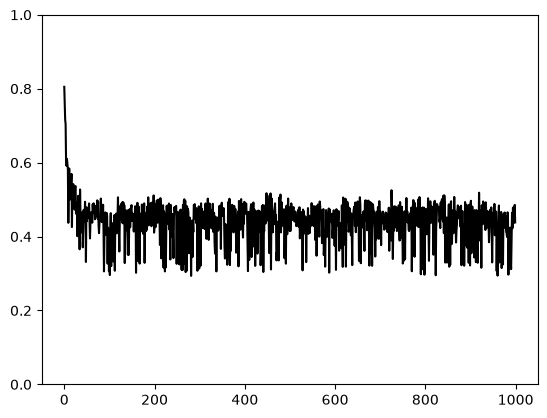

In [29]:
import matplotlib.pyplot as plt

iteration = list(range(ITERATION_COUNT))

plt.plot(
    iteration,
    total_acceptance_rate_history,
    color='black'
)
plt.ylim(0,1)

Program Code &copy; 2026 Miriam Derla, [GNU General Public License v3.0](https://www.gnu.org/licenses/). 